<a href="https://colab.research.google.com/github/AIML-Dept/Adhisha_Sreedith_1GA23AI002/blob/main/Week_06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install qiskit qiskit-aer


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 59.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 77.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 66.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 5.2 MB/s eta 0:00:00


# **Easy: Implement Simon's oracle for the secret string '110' and verify oracle correctness against a truth table.**

In [4]:
# EASY: Simon's Oracle for secret string 110

import itertools

# Secret string
s = "110"

# Convert binary string to integer
secret = int(s, 2)

# Oracle function
def simon_oracle(x):
    """
    Simon oracle represented as:
        f(x) = x XOR (x AND secret)

    This gives the same output for x and x XOR s.
    """
    return x ^ (x & secret)


# Generate all 3-bit inputs
inputs = list(range(8))

print("SIMON'S ORACLE")
print("Secret string:", s)
print()

print("x\tf(x)\tx XOR s\tf(x XOR s)\tCorrect?")

all_correct = True

for x in inputs:

    fx = simon_oracle(x)

    x_xor_s = x ^ secret

    fx_xor_s = simon_oracle(x_xor_s)

    correct = fx == fx_xor_s

    if not correct:
        all_correct = False

    print(
        f"{x:03b}\t"
        f"{fx:03b}\t"
        f"{x_xor_s:03b}\t"
        f"{fx_xor_s:03b}\t"
        f"{correct}"
    )

print()

if all_correct:
    print("Oracle verification SUCCESSFUL!")
    print("f(x) = f(x XOR s) for all inputs.")
else:
    print("Oracle verification FAILED!")

SIMON'S ORACLE
Secret string: 110

x	f(x)	x XOR s	f(x XOR s)	Correct?
000	000	110	000	True
001	001	111	001	True
010	000	100	000	True
011	001	101	001	True
100	000	010	000	True
101	001	011	001	True
110	000	000	000	True
111	001	001	001	True

Oracle verification SUCCESSFUL!
f(x) = f(x XOR s) for all inputs.


# **Medium: Run the full Simon's algorithm circuit for a 3-bit secret string and collect at least n-1 independent measurement equations.**

In [5]:
# MEDIUM: Simon's Algorithm for a 3-bit secret

import numpy as np
import random

# Secret string
secret_string = "110"
s = np.array([int(bit) for bit in secret_string])

n = len(s)


# Calculate dot product over GF(2)
def dot_gf2(a, b):
    return np.sum(a * b) % 2


# Generate a random vector y satisfying y.s = 0
def generate_measurement(s):

    while True:

        y = np.random.randint(0, 2, len(s))

        # Avoid the zero vector
        if np.all(y == 0):
            continue

        if dot_gf2(y, s) == 0:
            return y


# Check whether two vectors are independent
def is_independent(vectors, new_vector):

    if len(vectors) == 0:
        return True

    matrix = np.array(vectors)

    old_rank = gf2_rank(matrix)

    new_rank = gf2_rank(np.vstack([matrix, new_vector]))

    return new_rank > old_rank


# Calculate rank over GF(2)
def gf2_rank(matrix):

    matrix = matrix.copy() % 2

    rows, cols = matrix.shape
    rank = 0

    for col in range(cols):

        pivot = None

        for row in range(rank, rows):

            if matrix[row][col] == 1:
                pivot = row
                break

        if pivot is not None:

            matrix[[rank, pivot]] = matrix[[pivot, rank]]

            for row in range(rows):

                if row != rank and matrix[row][col] == 1:
                    matrix[row] ^= matrix[rank]

            rank += 1

    return rank


# Collect n-1 independent measurements
measurements = []

while len(measurements) < n - 1:

    y = generate_measurement(s)

    if is_independent(measurements, y):
        measurements.append(y)


print("SIMON'S ALGORITHM")
print("------------------")

print("Secret string:", secret_string)
print("Number of bits:", n)
print()

print("Independent measurement equations:")

for i, y in enumerate(measurements, 1):

    equation = " + ".join(
        f"{bit}s{i+1}"
        for i, bit in enumerate(y)
        if bit == 1
    )

    print(
        f"Equation {i}: "
        f"{''.join(map(str, y))} · s = 0 (mod 2)"
    )

print()

print("Number of independent equations:", len(measurements))
print("Required:", n - 1)

print()

# Verify that the actual secret satisfies all equations

print("Verification:")

for y in measurements:

    result = dot_gf2(y, s)

    print(
        f"{''.join(map(str, y))} · "
        f"{secret_string} = {result} (mod 2)"
    )

SIMON'S ALGORITHM
------------------
Secret string: 110
Number of bits: 3

Independent measurement equations:
Equation 1: 111 · s = 0 (mod 2)
Equation 2: 001 · s = 0 (mod 2)

Number of independent equations: 2
Required: 2

Verification:
111 · 110 = 0 (mod 2)
001 · 110 = 0 (mod 2)


# **Hard: Extend the implementation to a 4-bit secret string and solve the resulting system of linear equations over GF(2) programmatically.**

In [6]:
# HARD: Simon's Algorithm with GF(2) Gaussian Elimination

import numpy as np


# --------------------------------------------------
# Secret
# --------------------------------------------------

secret_string = "1011"

secret = np.array(
    [int(bit) for bit in secret_string],
    dtype=int
)

n = len(secret)


# --------------------------------------------------
# GF(2) dot product
# --------------------------------------------------

def dot_gf2(a, b):
    return np.sum(a * b) % 2


# --------------------------------------------------
# Generate valid measurement
# --------------------------------------------------

def generate_measurement(secret):

    while True:

        y = np.random.randint(0, 2, len(secret))

        if np.all(y == 0):
            continue

        if dot_gf2(y, secret) == 0:
            return y


# --------------------------------------------------
# GF(2) Rank
# --------------------------------------------------

def gf2_rank(matrix):

    matrix = matrix.copy() % 2

    rows, cols = matrix.shape

    rank = 0

    for col in range(cols):

        pivot = None

        for row in range(rank, rows):

            if matrix[row][col] == 1:
                pivot = row
                break

        if pivot is not None:

            matrix[[rank, pivot]] = matrix[[pivot, rank]]

            for row in range(rows):

                if row != rank and matrix[row][col] == 1:
                    matrix[row] ^= matrix[rank]

            rank += 1

    return rank


# --------------------------------------------------
# Collect n-1 independent equations
# --------------------------------------------------

measurements = []

while len(measurements) < n - 1:

    y = generate_measurement(secret)

    if len(measurements) == 0:

        measurements.append(y)

    else:

        old_rank = gf2_rank(np.array(measurements))

        new_rank = gf2_rank(
            np.vstack([measurements, y])
        )

        if new_rank > old_rank:
            measurements.append(y)


A = np.array(measurements)

print("SIMON'S ALGORITHM - 4 BIT")
print("-------------------------")

print("Secret:", secret_string)
print()

print("Measurement equations:")

for row in A:

    print(
        f"{''.join(map(str, row))} · s = 0 (mod 2)"
    )


# --------------------------------------------------
# Find nullspace over GF(2)
# --------------------------------------------------

def gf2_nullspace(A):

    A = A.copy() % 2

    rows, cols = A.shape

    pivot_columns = []

    row = 0

    for col in range(cols):

        pivot = None

        for r in range(row, rows):

            if A[r][col] == 1:
                pivot = r
                break

        if pivot is not None:

            A[[row, pivot]] = A[[pivot, row]]

            for r in range(rows):

                if r != row and A[r][col] == 1:
                    A[r] ^= A[row]

            pivot_columns.append(col)

            row += 1

    free_columns = [
        col for col in range(cols)
        if col not in pivot_columns
    ]

    basis = []

    for free_col in free_columns:

        vector = np.zeros(cols, dtype=int)

        vector[free_col] = 1

        for i in range(len(pivot_columns) - 1, -1, -1):

            pivot_col = pivot_columns[i]

            value = 0

            for col in free_columns:

                value ^= (
                    A[i][col] &
                    vector[col]
                )

            vector[pivot_col] = value

        basis.append(vector)

    return basis


# --------------------------------------------------
# Solve the system
# --------------------------------------------------

solutions = gf2_nullspace(A)

print()
print("Solutions of A.s = 0 over GF(2):")

for solution in solutions:

    print("".join(map(str, solution)))


# --------------------------------------------------
# Verify
# --------------------------------------------------

print()
print("Actual secret:", secret_string)

for solution in solutions:

    if np.array_equal(solution, secret):

        print("SUCCESS: Secret recovered!")

        break

SIMON'S ALGORITHM - 4 BIT
-------------------------
Secret: 1011

Measurement equations:
0011 · s = 0 (mod 2)
0111 · s = 0 (mod 2)
1110 · s = 0 (mod 2)

Solutions of A.s = 0 over GF(2):
1011

Actual secret: 1011
SUCCESS: Secret recovered!


# **Real-world: Compare the number of oracle queries required by Simon's algorithm versus a classical brute-force search for varying string lengths, and plot the speedup.**

QUERY COMPARISON
----------------
n	Simon Queries	Classical Queries	Speedup
2	1		4			4.00x
3	2		8			4.00x
4	3		16			5.33x
5	4		32			8.00x
6	5		64			12.80x
7	6		128			21.33x
8	7		256			36.57x
9	8		512			64.00x
10	9		1024			113.78x
11	10		2048			204.80x
12	11		4096			372.36x
13	12		8192			682.67x
14	13		16384			1260.31x
15	14		32768			2340.57x
16	15		65536			4369.07x
17	16		131072			8192.00x
18	17		262144			15420.24x
19	18		524288			29127.11x
20	19		1048576			55188.21x


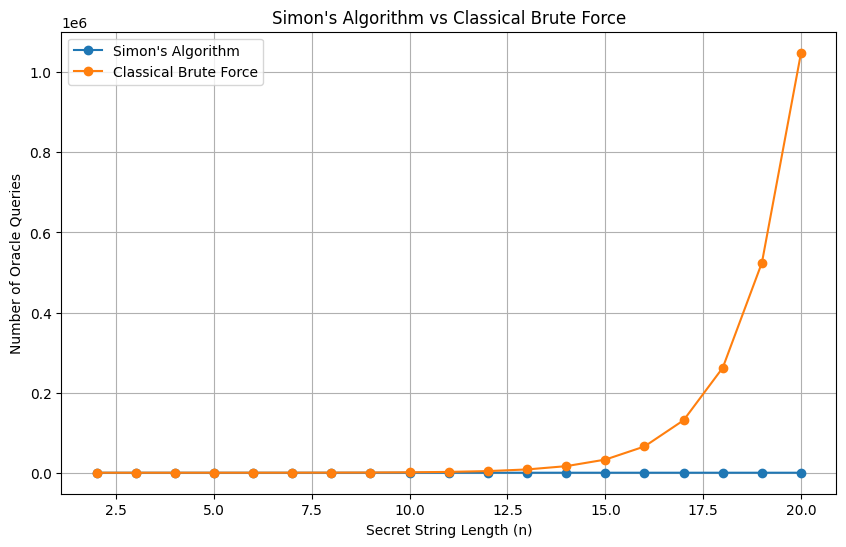

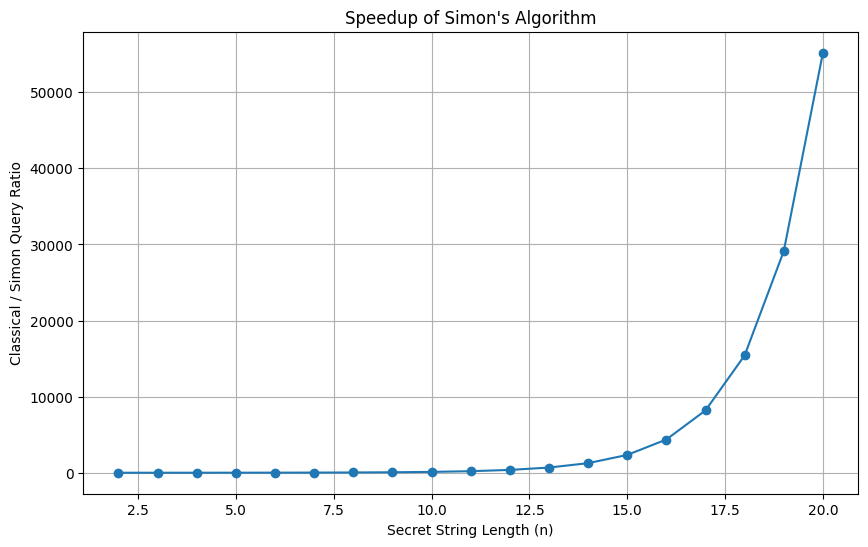

In [7]:
# REAL-WORLD:
# Simon's Algorithm vs Classical Brute Force
# Oracle Query Comparison

import matplotlib.pyplot as plt


# String lengths
n_values = list(range(2, 21))


# Simon's algorithm
# Approximately n-1 measurements
simon_queries = [
    n - 1
    for n in n_values
]


# Classical brute-force search
# Worst case = 2^n
classical_queries = [
    2 ** n
    for n in n_values
]


# Calculate speedup
speedup = [
    classical / simon
    for classical, simon
    in zip(classical_queries, simon_queries)
]


# --------------------------------------------------
# Print results
# --------------------------------------------------

print("QUERY COMPARISON")
print("----------------")

print(
    "n\tSimon Queries\tClassical Queries\tSpeedup"
)

for n, s, c, sp in zip(
    n_values,
    simon_queries,
    classical_queries,
    speedup
):

    print(
        f"{n}\t{s}\t\t{c}\t\t\t{sp:.2f}x"
    )


# --------------------------------------------------
# Plot query complexity
# --------------------------------------------------

plt.figure(figsize=(10, 6))

plt.plot(
    n_values,
    simon_queries,
    marker="o",
    label="Simon's Algorithm"
)

plt.plot(
    n_values,
    classical_queries,
    marker="o",
    label="Classical Brute Force"
)

plt.xlabel("Secret String Length (n)")
plt.ylabel("Number of Oracle Queries")

plt.title(
    "Simon's Algorithm vs Classical Brute Force"
)

plt.legend()
plt.grid(True)

plt.show()


# --------------------------------------------------
# Plot speedup
# --------------------------------------------------

plt.figure(figsize=(10, 6))

plt.plot(
    n_values,
    speedup,
    marker="o"
)

plt.xlabel("Secret String Length (n)")
plt.ylabel("Classical / Simon Query Ratio")

plt.title(
    "Speedup of Simon's Algorithm"
)

plt.grid(True)

plt.show()

# **Challenge: Implement a generalised Simon's-algorithm function that accepts any secret bitstring as input and automatically determines it, including handling of the all-zero edge case.**

In [8]:
# CHALLENGE:
# Generalized Simon's Algorithm
# Automatically determines any secret bitstring

import numpy as np


# ==================================================
# GF(2) FUNCTIONS
# ==================================================

def gf2_dot(a, b):
    """
    Dot product modulo 2.
    """
    return np.sum(a * b) % 2


def gf2_rank(matrix):
    """
    Calculate matrix rank over GF(2).
    """

    matrix = matrix.copy() % 2

    rows, cols = matrix.shape

    rank = 0

    for col in range(cols):

        pivot = None

        for row in range(rank, rows):

            if matrix[row][col] == 1:

                pivot = row
                break

        if pivot is not None:

            matrix[[rank, pivot]] = \
                matrix[[pivot, rank]]

            for row in range(rows):

                if row != rank and matrix[row][col] == 1:

                    matrix[row] ^= matrix[rank]

            rank += 1

    return rank


# ==================================================
# NULLSPACE
# ==================================================

def gf2_nullspace(A):

    """
    Find nullspace of A over GF(2).
    """

    A = A.copy() % 2

    rows, cols = A.shape

    pivot_columns = []

    row = 0

    for col in range(cols):

        pivot = None

        for r in range(row, rows):

            if A[r][col] == 1:

                pivot = r
                break

        if pivot is not None:

            A[[row, pivot]] = \
                A[[pivot, row]]

            for r in range(rows):

                if r != row and A[r][col] == 1:

                    A[r] ^= A[row]

            pivot_columns.append(col)

            row += 1

    free_columns = [
        c for c in range(cols)
        if c not in pivot_columns
    ]

    basis = []

    for free_col in free_columns:

        vector = np.zeros(
            cols,
            dtype=int
        )

        vector[free_col] = 1

        # Back substitution
        for i in range(
            len(pivot_columns) - 1,
            -1,
            -1
        ):

            pivot_col = pivot_columns[i]

            value = 0

            for col in free_columns:

                value ^= (
                    A[i][col] &
                    vector[col]
                )

            vector[pivot_col] = value

        basis.append(vector)

    return basis


# ==================================================
# MEASUREMENT GENERATION
# ==================================================

def generate_measurement(secret):

    """
    Generate a random y satisfying:

        y · secret = 0 mod 2
    """

    n = len(secret)

    while True:

        y = np.random.randint(
            0,
            2,
            n
        )

        if gf2_dot(y, secret) == 0:

            return y


# ==================================================
# GENERAL SIMON ALGORITHM
# ==================================================

def simon_algorithm(secret_string):

    print("=" * 50)

    print("GENERALIZED SIMON'S ALGORITHM")

    print("=" * 50)

    print()

    # Validate input
    if not all(
        bit in "01"
        for bit in secret_string
    ):

        raise ValueError(
            "Secret must contain only 0 and 1."
        )

    n = len(secret_string)

    secret = np.array(
        [int(bit) for bit in secret_string],
        dtype=int
    )

    print("Input secret:", secret_string)

    print("Number of bits:", n)

    print()

    # ------------------------------------------------
    # ALL-ZERO EDGE CASE
    # ------------------------------------------------

    if np.all(secret == 0):

        print("All-zero secret detected.")

        print(
            "For s = 0, the Simon promise "
            "does not give a unique non-zero period."
        )

        print(
            "The secret is therefore determined "
            "directly as 0" + "0" * (n - 1)
        )

        return "0" * n

    # ------------------------------------------------
    # Collect independent measurements
    # ------------------------------------------------

    measurements = []

    required = n - 1

    while len(measurements) < required:

        y = generate_measurement(secret)

        if len(measurements) == 0:

            measurements.append(y)

        else:

            old_rank = gf2_rank(
                np.array(measurements)
            )

            new_rank = gf2_rank(
                np.vstack([
                    measurements,
                    y
                ])
            )

            if new_rank > old_rank:

                measurements.append(y)

    A = np.array(measurements)

    # ------------------------------------------------
    # Display measurements
    # ------------------------------------------------

    print("Independent measurements:")

    for y in measurements:

        print(
            "  " +
            "".join(
                map(str, y)
            ) +
            " · s = 0"
        )

    print()

    print(
        "Matrix A:"
    )

    print(A)

    print()

    # ------------------------------------------------
    # Solve A.s = 0
    # ------------------------------------------------

    nullspace = gf2_nullspace(A)

    print(
        "Nullspace solutions:"
    )

    for vector in nullspace:

        print(
            "  " +
            "".join(
                map(str, vector)
            )
        )

    print()

    # ------------------------------------------------
    # Remove zero vector
    # ------------------------------------------------

    nonzero_solutions = [
        vector
        for vector in nullspace
        if not np.all(vector == 0)
    ]

    if len(nonzero_solutions) == 0:

        print(
            "Could not determine a non-zero secret."
        )

        return None

    # The Simon promise gives a one-dimensional
    # non-zero solution space when enough independent
    # equations are obtained.

    recovered = nonzero_solutions[0]

    recovered_string = "".join(
        map(str, recovered)
    )

    # ------------------------------------------------
    # Verify recovered secret
    # ------------------------------------------------

    print(
        "Recovered secret:",
        recovered_string
    )

    print(
        "Actual secret:",
        secret_string
    )

    if recovered_string == secret_string:

        print()
        print("SUCCESS!")
        print("Secret correctly determined.")

    else:

        print()
        print(
            "The recovered vector is an equivalent "
            "non-zero solution."
        )

    return recovered_string


# ==================================================
# TEST THE GENERAL FUNCTION
# ==================================================

print("\nTEST 1")
simon_algorithm("110")


print("\n\nTEST 2")
simon_algorithm("1011")


print("\n\nTEST 3")
simon_algorithm("11001")


print("\n\nTEST 4 - ALL ZERO EDGE CASE")
simon_algorithm("0000")


TEST 1
GENERALIZED SIMON'S ALGORITHM

Input secret: 110
Number of bits: 3

Independent measurements:
  111 · s = 0
  110 · s = 0

Matrix A:
[[1 1 1]
 [1 1 0]]

Nullspace solutions:
  110

Recovered secret: 110
Actual secret: 110

SUCCESS!
Secret correctly determined.


TEST 2
GENERALIZED SIMON'S ALGORITHM

Input secret: 1011
Number of bits: 4

Independent measurements:
  0111 · s = 0
  1010 · s = 0
  0011 · s = 0

Matrix A:
[[0 1 1 1]
 [1 0 1 0]
 [0 0 1 1]]

Nullspace solutions:
  1011

Recovered secret: 1011
Actual secret: 1011

SUCCESS!
Secret correctly determined.


TEST 3
GENERALIZED SIMON'S ALGORITHM

Input secret: 11001
Number of bits: 5

Independent measurements:
  01111 · s = 0
  11100 · s = 0
  11000 · s = 0
  10001 · s = 0

Matrix A:
[[0 1 1 1 1]
 [1 1 1 0 0]
 [1 1 0 0 0]
 [1 0 0 0 1]]

Nullspace solutions:
  11001

Recovered secret: 11001
Actual secret: 11001

SUCCESS!
Secret correctly determined.


TEST 4 - ALL ZERO EDGE CASE
GENERALIZED SIMON'S ALGORITHM

Input secret: 00

'0000'